**TWIN FAIRY TACTICIANS**
- Aguarin, Trish Ann Danielle C.
- Cabato, Marxandrea Diane G.

# Breast Cancer

Breast cancer is one of the most common malignancies affecting women worldwide, making early detection a top priority for improving patient survival rates. While ultrasound imaging is a vital, non-invasive diagnostic tool, interpreting these scans can be difficult and subjective, often leading to variations in diagnosis. To address this, machine learning can be used to analyze complex patterns in the images that might be missed by the human eye. By evaluating a range of models—from traditional methods like Random Forest to advanced deep learning architectures like ResNet50—this project explores how computational tools can provide a reliable "second opinion." The goal is to determine the most effective way to **predict breast cancer class (whether benign, malignant, or normal) based on ultrasound images of breasts**.

# Imports and Initialization of Seed

In [ ]:
import random
import time
import seaborn as sns

import pandas as pd
from pathlib import Path

import numpy as np
from PIL import Image

import matplotlib.pyplot as plt
import cv2

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay

from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint


from data_utils import (
    get_dataset_paths,
    get_label_from_mask,
    load_busi_dataset,
    load_bus_uclm_dataset,
    merge_image_and_mask_datasets,
    )
from preprocessing_utils import (
    augment_target_class,
    summarize_augmentation,
    flatten_images,
    convert_grayscale_to_rgb,
    )
from model_utils import (
    create_random_forest,
    build_mobilenet_basic,
    build_mobilenet_improved,
    build_mobilenet_final,
    build_resnet50_basic,
    )
from evaluation_utils import (
    evaluate_sklearn_classifier,
    evaluate_keras_classifier,
    plot_training_history,
    compare_model_accuracies,
    plot_side_by_side_confusion_matrices,
    plot_all_confusion_matrices,
    )

In [5]:
SEED = 22
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Breast Ultrasound Datasets

For this project, we will be combining two breast ultrasound datasets, BUSI and BUS-UCLM, to have more images to work with. 

In [6]:
datasets_dir, BUSI_ROOT, BUS_UCLM_ROOT = get_dataset_paths()

print('Datasets directory:', datasets_dir)
print('BUSI exists:', BUSI_ROOT.exists())
print('BUS-UCLM exists:', BUS_UCLM_ROOT.exists())

Datasets directory: c:\Users\marxa\OneDrive\Documents\GitHub\CSC713M-Breast-Cancer-Classification\Datasets
BUSI exists: True
BUS-UCLM exists: True


## BUSI Dataset

The BUSI Dataset contains a total of 780 images. Benign, malignant, and normal classes are said to contain 437, 210, and 133 images each, respectively. The ultrasound images also come with their masked versions, which we will be exluding in this project. Initially, this was the only dataset we were supposed to use; however, since there is a visible class imbalance on top of the minimal number of images for all classes, we have decided to look for another dataset.

Below, we will run through the dataset to extract the labels along with the images, and verify if the numbers correspond with the documentation.

In [7]:
dataset_root = BUSI_ROOT
df_busi_images = load_busi_dataset(dataset_root)

print(f"\n{'='*60}")
print('Dataset_BUSI Summary')
print(f"{'='*60}")
print(f"Images: {len(df_busi_images)}")
print('\nImage distribution:')
print(df_busi_images['label'].value_counts().sort_index())
print(f"{'='*60}")


Dataset_BUSI Summary
Images: 780

Image distribution:
label
benign       437
malignant    210
normal       133
Name: count, dtype: int64


### BUSI Class Distribution Visualization

The charts below visualize BUSI class counts and percentage composition to complement the printed summary.

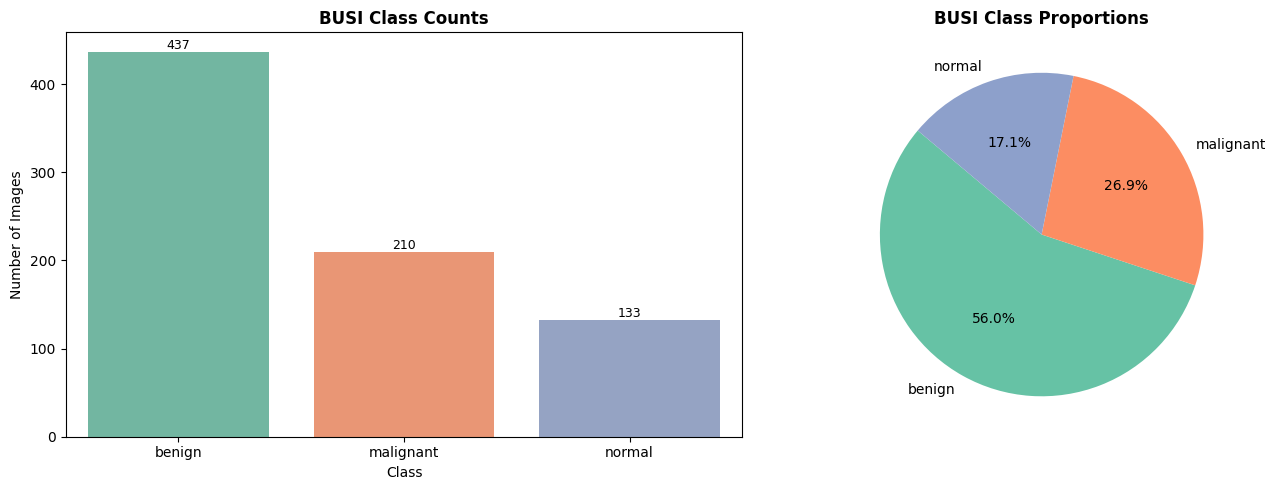

In [8]:
busi_counts = df_busi_images['label'].value_counts().sort_index()
busi_percentages = busi_counts / busi_counts.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    x=busi_counts.index,
    y=busi_counts.values,
    hue=busi_counts.index,
    palette='Set2',
    legend=False,
    ax=axes[0],
    )
axes[0].set_title('BUSI Class Counts', fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Number of Images')
for i, count in enumerate(busi_counts.values):
    axes[0].text(i, count + 3, str(count), ha='center', fontsize=9)

axes[1].pie(
    busi_percentages.values,
    labels=busi_percentages.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('Set2', len(busi_percentages)),
    )
axes[1].set_title('BUSI Class Proportions', fontweight='bold')

plt.tight_layout()
plt.show()

The numbers correspond to the documentation. We can proceed to the next dataset.

## BUS-UCLM Dataset

The BUS-UCLM Dataset contains a total of 683 images. Benign, malignant, and normal classes are said to contain 174, 90, and 419 images each, respectively. The ultrasound images also come with their masked versions, which we will be exluding in this project.

Below, we will run through the dataset to extract the labels along with the images, and verify if the numbers correspond with the documentation.

### Label Extraction

We will first begin by determining the label of each image. Unlike the first dataset, this dataset does not directly contain the label. Rather, the label is presented as a segmentation mask with a corresponding color. Red for malignant, green for benign, and black for normal.

In [9]:
df_bus_uclm_images = load_bus_uclm_dataset(BUS_UCLM_ROOT)

print(f"\n{'='*60}")
print('BUS-UCLM Summary')
print(f"{'='*60}")
print(f"Images with labels: {len(df_bus_uclm_images)}")
print('\nLabel distribution:')
if not df_bus_uclm_images.empty and 'label' in df_bus_uclm_images.columns:
    print(df_bus_uclm_images['label'].value_counts().sort_index())
else:
    print("No images processed or 'label' column not found.")
print(f"{'='*60}")


BUS-UCLM Summary
Images with labels: 683

Label distribution:
label
benign       174
malignant     90
normal       419
Name: count, dtype: int64


### BUS-UCLM Class Distribution Visualization

The charts below visualize BUS-UCLM class counts and percentage composition to complement the printed summary.

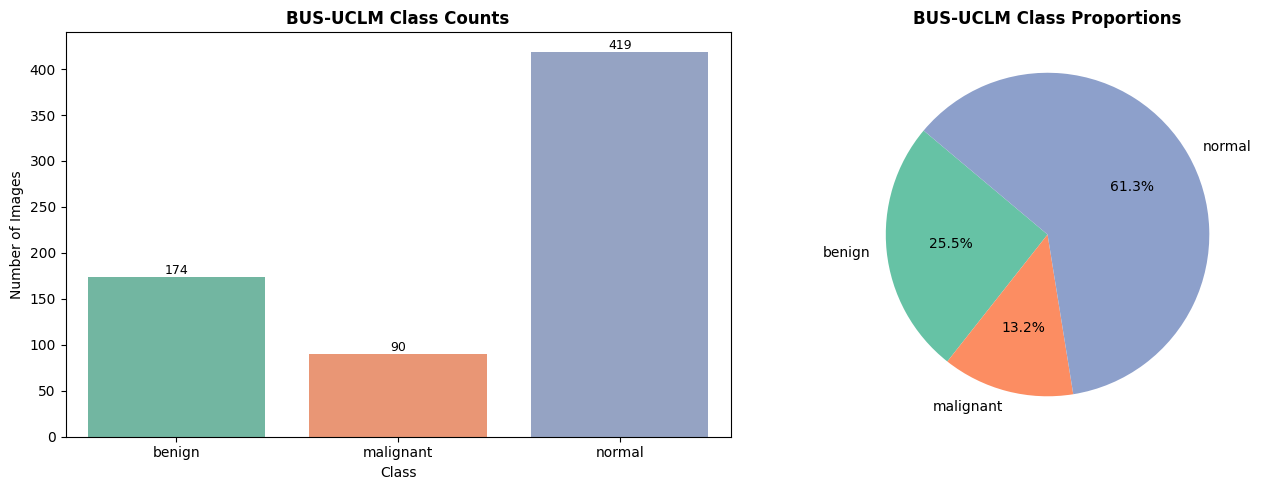

In [10]:
if not df_bus_uclm_images.empty and 'label' in df_bus_uclm_images.columns:
    bus_uclm_counts = df_bus_uclm_images['label'].value_counts().sort_index()
    bus_uclm_percentages = bus_uclm_counts / bus_uclm_counts.sum() * 100

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.barplot(
        x=bus_uclm_counts.index,
        y=bus_uclm_counts.values,
        hue=bus_uclm_counts.index,
        palette='Set2',
        legend=False,
        ax=axes[0],
        )
    axes[0].set_title('BUS-UCLM Class Counts', fontweight='bold')
    axes[0].set_xlabel('Class')
    axes[0].set_ylabel('Number of Images')
    for i, count in enumerate(bus_uclm_counts.values):
        axes[0].text(i, count + 3, str(count), ha='center', fontsize=9)

    axes[1].pie(
        bus_uclm_percentages.values,
        labels=bus_uclm_percentages.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=sns.color_palette('Set2', len(bus_uclm_percentages)),
        )
    axes[1].set_title('BUS-UCLM Class Proportions', fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print("BUS-UCLM visualization skipped: no labeled data available.")

After matching the images with the labels, the numbers appear to correspond to the documentation. We can now merge our datasets.

## Merge Datasets

Since we have succefully extracted the images and labels from both datasets, we can now merge them. We will be working with the merged dataset for this project.

In [11]:
df_all_images = merge_image_and_mask_datasets(
    df_busi_images,
    df_bus_uclm_images,
    )

print(f"\n{'='*60}")
print('MERGED DATASET SUMMARY')
print(f"{'='*60}")
print(f"Total images: {len(df_all_images)}")
print('\nImage class distribution:')
print(df_all_images['label'].value_counts().sort_index())
print('\nPercentage distribution:')
percentage = df_all_images['label'].value_counts(normalize=True).sort_index() * 100
for label, pct in percentage.items():
    print(f"  {label.capitalize()}: {pct:.2f}%")
print(f"\n{'='*60}")
print(f"Dataset_BUSI: {len(df_busi_images)} images")
print(f"BUS-UCLM: {len(df_bus_uclm_images)} images")
print(f"{'='*60}")


MERGED DATASET SUMMARY
Total images: 1463

Image class distribution:
label
benign       611
malignant    300
normal       552
Name: count, dtype: int64

Percentage distribution:
  Benign: 41.76%
  Malignant: 20.51%
  Normal: 37.73%

Dataset_BUSI: 780 images
BUS-UCLM: 683 images


### Class Distribution Overview

To better understand class balance, we visualize both raw counts and percentage composition of benign, malignant, and normal classes.

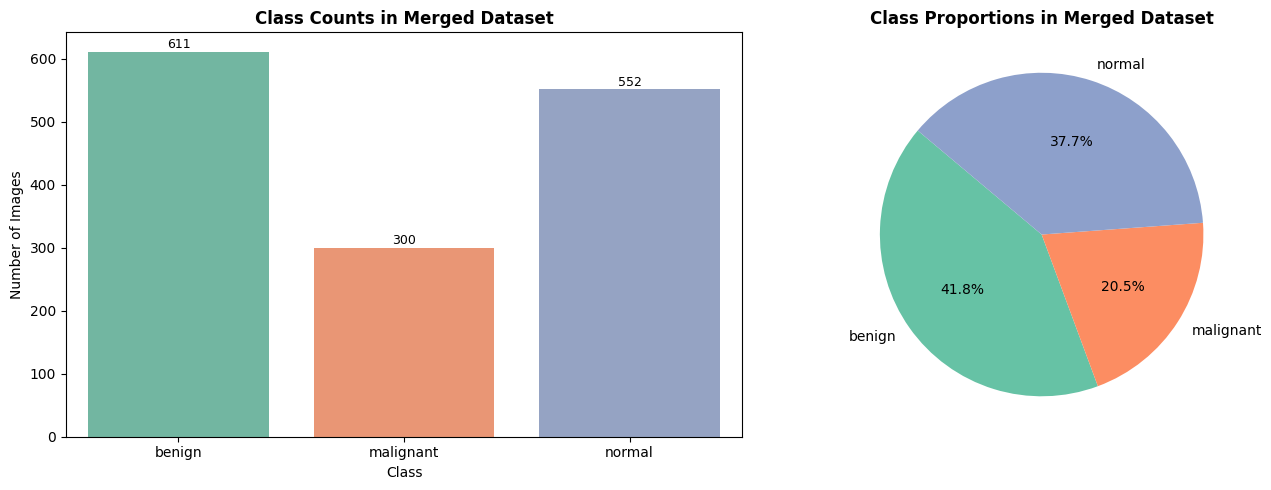

In [12]:
class_counts = df_all_images['label'].value_counts().sort_index()
class_percentages = class_counts / class_counts.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    x=class_counts.index,
    y=class_counts.values,
    hue=class_counts.index,
    palette='Set2',
    legend=False,
    ax=axes[0],
    )
axes[0].set_title('Class Counts in Merged Dataset', fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Number of Images')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=9)

axes[1].pie(
    class_percentages.values,
    labels=class_percentages.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('Set2', len(class_percentages)),
    )
axes[1].set_title('Class Proportions in Merged Dataset', fontweight='bold')

plt.tight_layout()
plt.show()

### Merged Dataset Image Quality Check (Before Preprocessing)

We analyze brightness, contrast, and edge strength on the merged raw images to justify enhancement steps such as CLAHE.

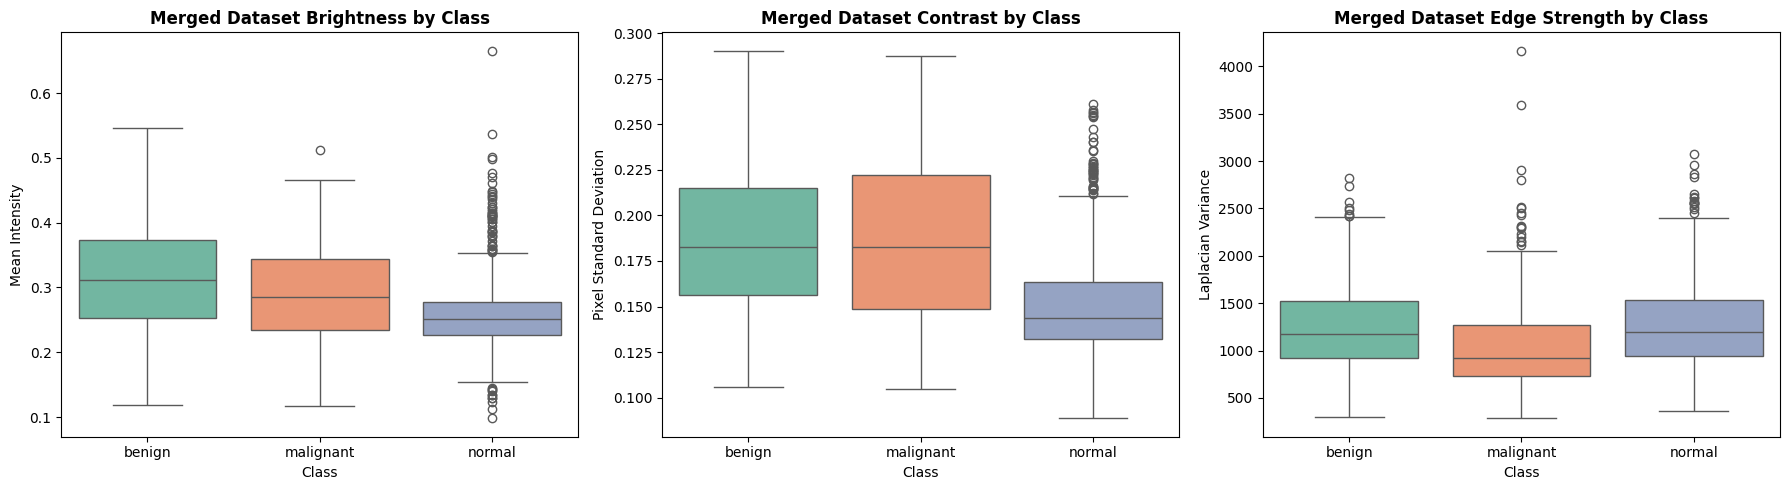

In [13]:
merged_quality_rows = []
for _, row in df_all_images.iterrows():
    img = cv2.imread(row['image_path'], cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue

    img = cv2.resize(img, (128, 128), interpolation=cv2.INTER_AREA)
    merged_quality_rows.append({
        'label': row['label'],
        'mean_intensity': img.mean() / 255.0,
        'contrast_std': img.std() / 255.0,
        'edge_strength': cv2.Laplacian(img, cv2.CV_64F).var(),
    })

merged_quality_df = pd.DataFrame(merged_quality_rows)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(data=merged_quality_df, x='label', y='mean_intensity', hue='label', palette='Set2', legend=False, ax=axes[0])
axes[0].set_title('Merged Dataset Brightness by Class', fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Mean Intensity')

sns.boxplot(data=merged_quality_df, x='label', y='contrast_std', hue='label', palette='Set2', legend=False, ax=axes[1])
axes[1].set_title('Merged Dataset Contrast by Class', fontweight='bold')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Pixel Standard Deviation')

sns.boxplot(data=merged_quality_df, x='label', y='edge_strength', hue='label', palette='Set2', legend=False, ax=axes[2])
axes[2].set_title('Merged Dataset Edge Strength by Class', fontweight='bold')
axes[2].set_xlabel('Class')
axes[2].set_ylabel('Laplacian Variance')

plt.tight_layout()
plt.show()

## Visualization

Below is a visualization of selected images from each class.

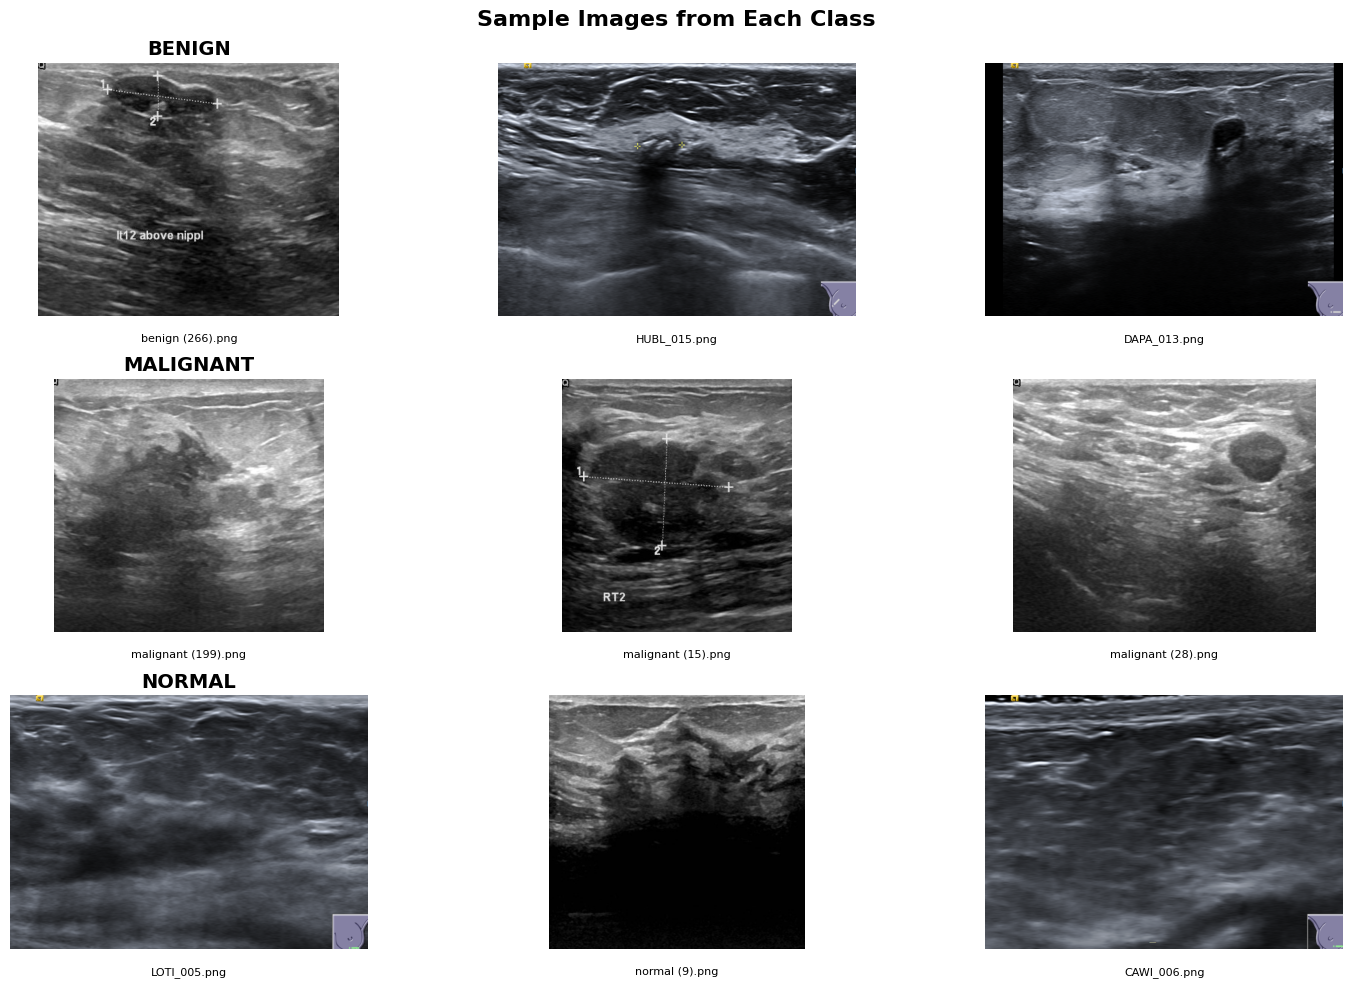

In [14]:
classes = sorted(df_all_images['label'].unique())
samples_per_class = 3
fig, axes = plt.subplots(len(classes), samples_per_class, figsize=(15, 10))

if len(classes) == 1:
    axes = axes.reshape(1, -1)

for i, cls in enumerate(classes):
    class_samples = df_all_images[df_all_images['label'] == cls].sample(n=min(samples_per_class, len(df_all_images[df_all_images['label'] == cls])), random_state=SEED)

    for j, (idx, row) in enumerate(class_samples.iterrows()):
        img = Image.open(row['image_path'])
        axes[i, j].imshow(img, cmap='gray')
        axes[i, j].axis('off')

        if j == 0:
            axes[i, j].set_title(f"{cls.upper()}", fontsize=14, fontweight='bold')

        filename = Path(row['image_path']).name
        axes[i, j].text(0.5, -0.1, filename[:20],
                      transform=axes[i, j].transAxes,
                      ha='center', fontsize=8)

plt.suptitle('Sample Images from Each Class', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# Data Preprocessing

The preprocessing stage converts raw, inconsistent ultrasound scans into clean data that the models can easily interpret. First, all images are resized to 128x128 pixels to ensure a uniform input shape. They are then converted to grayscale to remove unnecessary color data, forcing the models to focus on the textures and shapes of the tumors rather than irrelevant tints.

To improve detection, CLAHE (Contrast Limited Adaptive Histogram Equalization) is applied to sharpen the edges and internal details of the tumors. This is vital for distinguishing between smooth Benign borders and the jagged margins typical of Malignant cases. Finally, the pixel values are normalized to a range of [0, 1] to ensure faster and more stable training. This pipeline removes background noise and highlights the most important medical features.

These are being done within one loop for efficiency in terms of time.

In [15]:
target_size = (128, 128)

images = []
labels = []

print(f"Loading and preprocessing {len(df_all_images)} images...")

# Initialize CLAHE
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

for idx, row in tqdm(df_all_images.iterrows(), total=len(df_all_images)):
    try:
        img = cv2.imread(row['image_path'])

        # Convert to grayscale
        if len(img.shape) == 3:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # Resize to target size using cv2.INTER_AREA
        img = cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)

        # Apply CLAHE
        img = clahe.apply(img)

        # Normalize to [0, 1]
        img = img.astype(np.float32) / 255.0

        images.append(img)
        labels.append(row['label'])

    except Exception as e:
        print(f"Error processing {row['image_path']}: {e}")
        continue

X = np.array(images)
y = np.array(labels)

# Add channel dimension for grayscale images (batch_size, height, width, 1)
X = np.expand_dims(X, axis=-1)

print(f"\nSuccessfully loaded {len(X)} images")
print(f"  Image shape: {X.shape}")
print(f"  Pixel value range: [{X.min():.3f}, {X.max():.3f}]")

Loading and preprocessing 1463 images...


100%|██████████| 1463/1463 [00:11<00:00, 130.16it/s]


Successfully loaded 1463 images
  Image shape: (1463, 128, 128, 1)
  Pixel value range: [0.004, 1.000]


## Visualization: Original vs. Preprocessed Images

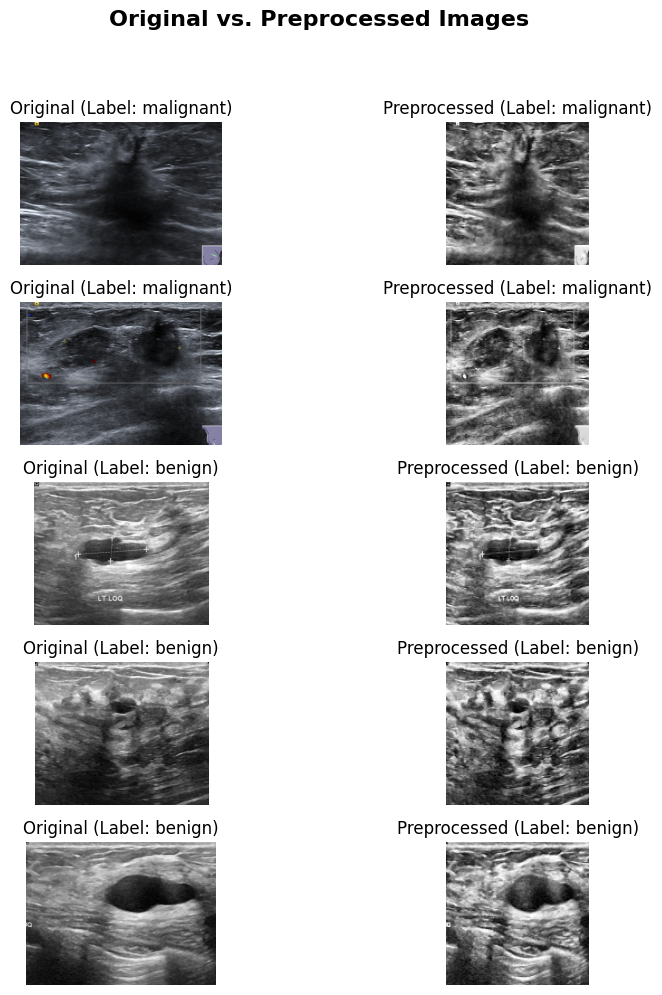

In [16]:
n_samples = 5

fig, axes = plt.subplots(n_samples, 2, figsize=(10, 2 * n_samples))
fig.suptitle('Original vs. Preprocessed Images', fontsize=16, fontweight='bold', y=1.02)

sample_indices = np.random.choice(len(df_all_images), n_samples, replace=False)

for i, original_idx in enumerate(sample_indices):
    row = df_all_images.iloc[original_idx]
    img_path = row['image_path']
    label = row['label']

    original_img_pil = Image.open(img_path).convert('RGB')
    axes[i, 0].imshow(original_img_pil)
    axes[i, 0].set_title(f"Original (Label: {label})")
    axes[i, 0].axis('off')

    preprocessed_img = X[original_idx]

    axes[i, 1].imshow(preprocessed_img[:, :, 0], cmap='gray')
    axes[i, 1].set_title(f"Preprocessed (Label: {label})")
    axes[i, 1].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

### Image Quality Exploration

We examine brightness, contrast, and edge strength in the preprocessed images to better understand image variability and possible sources of model difficulty.

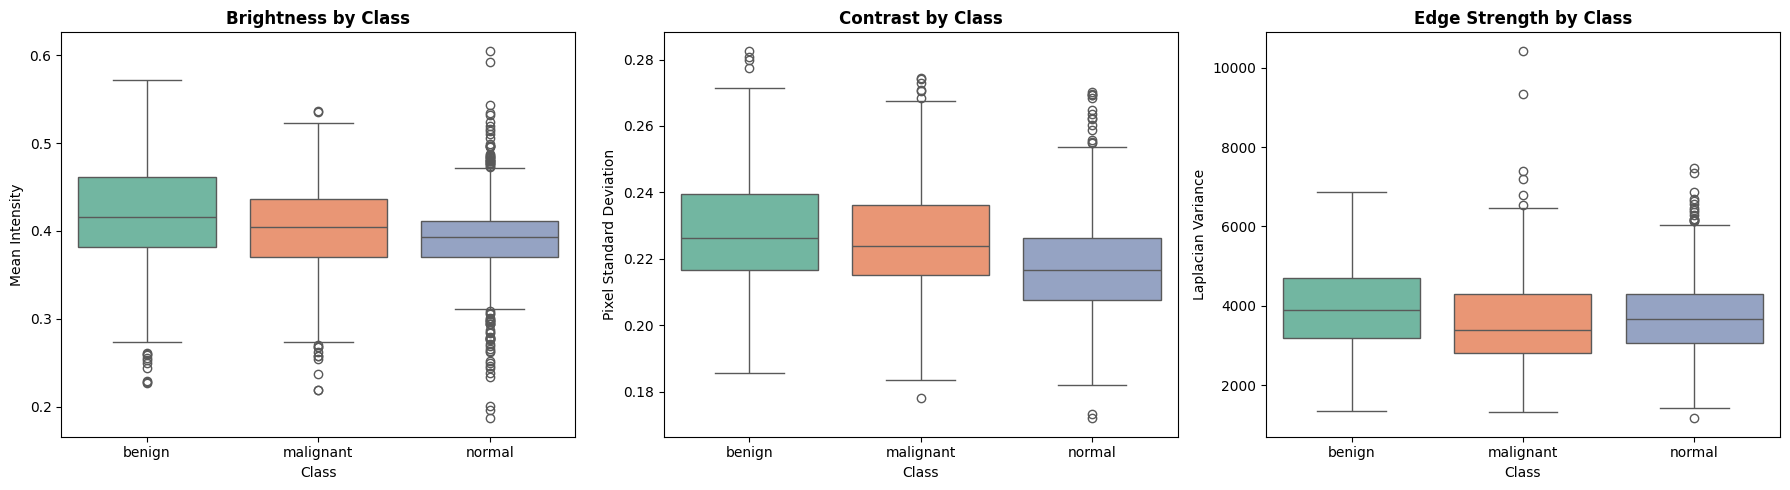

In [17]:
mean_intensity = X[:, :, :, 0].mean(axis=(1, 2))
std_intensity = X[:, :, :, 0].std(axis=(1, 2))
edge_strength = np.array([
    cv2.Laplacian((img[:, :, 0] * 255).astype(np.uint8), cv2.CV_64F).var()
    for img in X
    ])

image_quality_df = pd.DataFrame({
    'label': y,
    'mean_intensity': mean_intensity,
    'contrast_std': std_intensity,
    'edge_strength': edge_strength,
    })

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(
    data=image_quality_df,
    x='label',
    y='mean_intensity',
    hue='label',
    palette='Set2',
    legend=False,
    ax=axes[0],
    )
axes[0].set_title('Brightness by Class', fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Mean Intensity')

sns.boxplot(
    data=image_quality_df,
    x='label',
    y='contrast_std',
    hue='label',
    palette='Set2',
    legend=False,
    ax=axes[1],
    )
axes[1].set_title('Contrast by Class', fontweight='bold')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Pixel Standard Deviation')

sns.boxplot(
    data=image_quality_df,
    x='label',
    y='edge_strength',
    hue='label',
    palette='Set2',
    legend=False,
    ax=axes[2],
    )
axes[2].set_title('Edge Strength by Class', fontweight='bold')
axes[2].set_xlabel('Class')
axes[2].set_ylabel('Laplacian Variance')

plt.tight_layout()
plt.show()

## Label Encoding



In this section, we will convert our string labels (benign, malignant, normal) into integers (0, 1, 2). While random forest does not require integer labels, MobileNetV2 and ResNet50 both require integer targets; hence, we will stick to integer label encoding for consistency.

In [18]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [19]:
print("Label Encoding Mapping:")
for i, label in enumerate(label_encoder.classes_):
    print(f"  {label} -> {i}")

Label Encoding Mapping:
  benign -> 0
  malignant -> 1
  normal -> 2


# Data Preparation

In this section, we will be splitting our data into three: training, validation, and test. We will be following a distribution of 80-10-10. Since we have limited data, we also want each class to be distributed the same way.

In [20]:
# 80% train, 20% (10% val + 10% test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=SEED,
    stratify=y_encoded
)

In [21]:
# Split the 20% into 50% val and 50% test (each becomes 10%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=SEED,
    stratify=y_temp
)

Now, let us check if the dataset (and each class) has been distributed fairly among the three partitions.

In [22]:
print(f"\n{'='*60}")
print(f"Dataset Split Summary")
print(f"{'='*60}")
print(f"Training set:   {len(X_train)} images ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation set: {len(X_val)} images ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test set:       {len(X_test)} images ({len(X_test)/len(X)*100:.1f}%)")
print(f"{'='*60}")



Dataset Split Summary
Training set:   1170 images (80.0%)
Validation set: 146 images (10.0%)
Test set:       147 images (10.0%)


All appear to be distributed following the 80-10-10 distribution.

### Split Distribution Visualization

This plot checks whether each class remains proportionally represented across training, validation, and test sets.

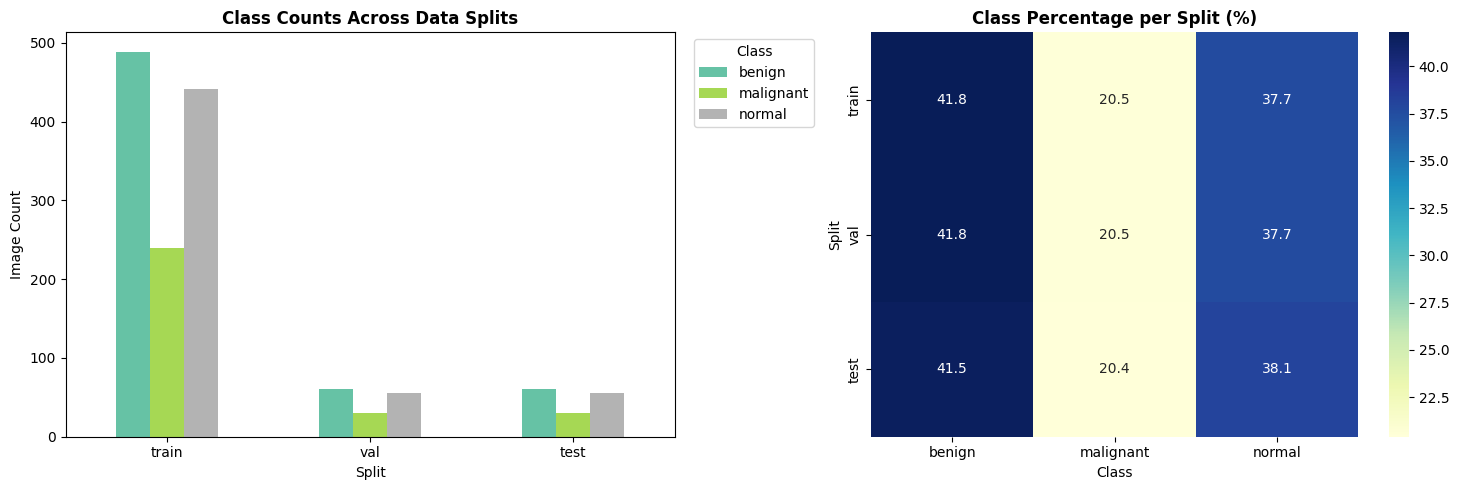

In [23]:
split_counts_df = pd.DataFrame({
    'train': pd.Series(y_train).value_counts().sort_index(),
    'val': pd.Series(y_val).value_counts().sort_index(),
    'test': pd.Series(y_test).value_counts().sort_index(),
    }).T

split_counts_df.columns = [label_encoder.classes_[i] for i in split_counts_df.columns]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

split_counts_df.plot(kind='bar', ax=axes[0], colormap='Set2')
axes[0].set_title('Class Counts Across Data Splits', fontweight='bold')
axes[0].set_xlabel('Split')
axes[0].set_ylabel('Image Count')
axes[0].legend(title='Class', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[0].tick_params(axis='x', rotation=0)

split_percent_df = split_counts_df.div(split_counts_df.sum(axis=1), axis=0) * 100
sns.heatmap(split_percent_df, annot=True, fmt='.1f', cmap='YlGnBu', ax=axes[1])
axes[1].set_title('Class Percentage per Split (%)', fontweight='bold')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Split')

plt.tight_layout()
plt.show()

All appear to be distributed equally across all sets.

## Data Augmentation

Currently, our malignant class makes up only approximately 20% of our overall data. Data augmentation will be done specifically for the malignant class in the training set so the number of samples becomes closer to benign and normal classes. We will apply one augmentation per malignant image: horizontal flip.

In [24]:
# Get the integer label for 'malignant'
malignant_label = label_encoder.transform(['malignant'])[0]

print(f"Original training set size: {len(X_train)}")
print(f"Malignant samples in training: {np.sum(y_train == malignant_label)}")

Original training set size: 1170
Malignant samples in training: 240


In [25]:
target_label = malignant_label
augmentation_factor = 1
augmentation_transforms = ['flip']

X_train_augmented, y_train_augmented = augment_target_class(
    X_train,
    y_train,
    target_label,
    augmentation_factor=augmentation_factor,
    transforms=augmentation_transforms,
    rotation_angle=15,
    )

Augmenting 240 images from target class...


100%|██████████| 240/240 [00:00<00:00, 18615.50it/s]


In [26]:
summarize_augmentation(
    X_train,
    X_train_augmented,
    y_train,
    y_train_augmented,
    label_encoder,
    target_label,
    )


Augmentation Results
Training set after augmentation: 1410 images
Increase: +240 images

Class distribution after augmentation:
  benign: 489 (34.68%)
  malignant: 480 (34.04%)
  normal: 441 (31.28%)

Target class augmented successfully!
  Before: 240 samples
  After:  480 samples


After augmentation, the malignant class proportion increases and the training distribution becomes more balanced.

## Visualization

Below is a visualization of a subset of the malignant class. It shows the original image and its flipped version, both included in the augmented training set.

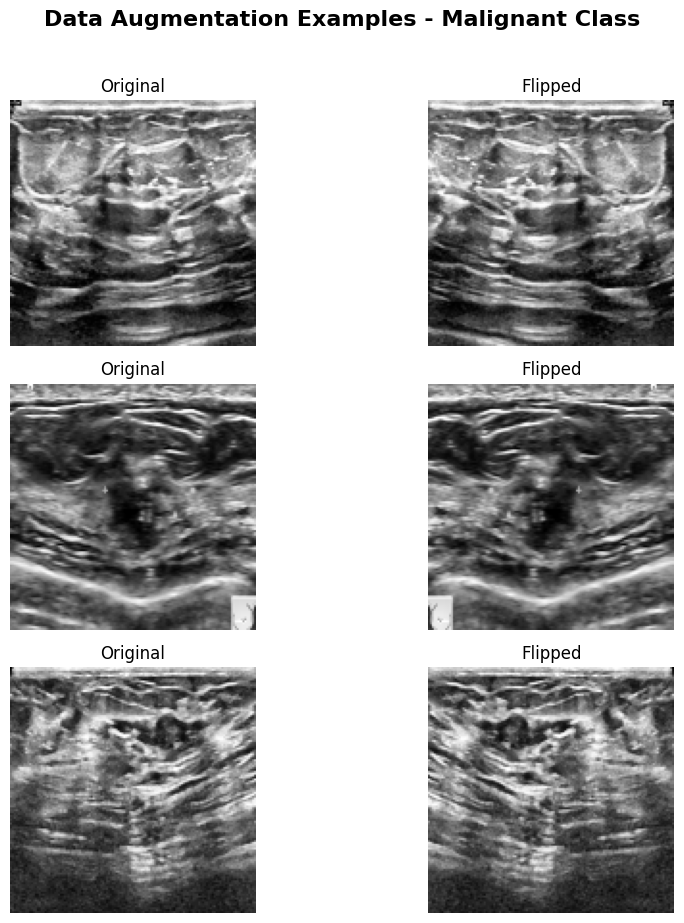

In [27]:
n_samples = 3
target_label = malignant_label
original_indices = np.where(y_train == target_label)[0][:n_samples]

fig, axes = plt.subplots(n_samples, 2, figsize=(10, 3*n_samples))

if n_samples == 1:
    axes = np.expand_dims(axes, axis=0)

for i, orig_idx in enumerate(original_indices):
    original_img = X_train[orig_idx][:, :, 0]
    flipped_img = cv2.flip(original_img, 1)

    axes[i, 0].imshow(original_img, cmap='gray')
    axes[i, 0].set_title('Original', fontsize=12)
    axes[i, 0].axis('off')

    axes[i, 1].imshow(flipped_img, cmap='gray')
    axes[i, 1].set_title('Flipped', fontsize=12)
    axes[i, 1].axis('off')

label_name = label_encoder.classes_[target_label]
plt.suptitle(
    f'Data Augmentation Examples - {label_name.capitalize()} Class',
    fontsize=16,
    fontweight='bold',
    y=1.02,
    )
plt.tight_layout()
plt.show()

# Data Summary

In [28]:
print(f"\nDataset Shapes:")
print(f"  X_train_augmented: {X_train_augmented.shape}")
print(f"  y_train_augmented: {y_train_augmented.shape}")
print(f"  X_val:             {X_val.shape}")
print(f"  y_val:             {y_val.shape}")
print(f"  X_test:            {X_test.shape}")
print(f"  y_test:            {y_test.shape}")

print(f"\nData Properties:")
print(f"  Image size: 128x128 pixels")
print(f"  Color space: Grayscale (1 channel)")
print(f"  Pixel range: [0.0, 1.0] (normalized)")
print(f"  Data type: {X_train_augmented.dtype}")

print(f"\nLabel Encoding:")
for i, label in enumerate(label_encoder.classes_):
    print(f"  {i} = {label}")



Dataset Shapes:
  X_train_augmented: (1410, 128, 128, 1)
  y_train_augmented: (1410,)
  X_val:             (146, 128, 128, 1)
  y_val:             (146,)
  X_test:            (147, 128, 128, 1)
  y_test:            (147,)

Data Properties:
  Image size: 128x128 pixels
  Color space: Grayscale (1 channel)
  Pixel range: [0.0, 1.0] (normalized)
  Data type: float32

Label Encoding:
  0 = benign
  1 = malignant
  2 = normal


# Baseline Model

## Random Forest

We will be using Random Forest as our first and baseline model as it is considered to be a strong non-deep-learning classifier that works well on tabularized image features. This will serve as our reference point for measuring the performance of the deep-learning models to be trained later on.

To accommodate the model’s architecture, the 2D ultrasound images will be flattened into one-dimensional feature vectors.

In [ ]:
print('Flattening images for Random Forest...')
print(f"Original shape: {X_train_augmented.shape}")

X_train_flat, X_val_flat, X_test_flat = flatten_images(
    X_train_augmented,
    X_val,
    X_test,
    )

print('\nFlattened shapes:')
print(f"  X_train_flat: {X_train_flat.shape}")
print(f"  X_val_flat:   {X_val_flat.shape}")
print(f"  X_test_flat:  {X_test_flat.shape}")

## Initializing Random Forest Classifier

In [ ]:
rf_model = create_random_forest(random_state=SEED)

print('\nModel Configuration:')
print('  Number of trees: 100')
print('  Class weighting: balanced')
print('  Random state: SEED')

## Test Set Evaluation

In [ ]:
rf_model.fit(X_train_flat, y_train_augmented)

y_test_pred, test_accuracy, report, cm = evaluate_sklearn_classifier(
    rf_model,
    X_test_flat,
    y_test,
    label_encoder,
    title='Random Forest Baseline',
    )

The Random Forest Classifier served as a decent baseline for this project, achieving an accuracy of 66.67%. This section established the limitations of classical machine learning when applied to raw medical imagery. Since the Random Forest Classifier operates on flattened pixel vectors, it treats each pixel as an independent variable, disabling the classifier to consider the spatial relationships and geometric strucures present in each image. This classifier also does not have the capacity to automatically extract features, hence why it only achieved the recorded accuracy.

The use of the Random Forest Classifier as our baseline model leads us to lean towards classification models that possess hierarchical spatial awareness rather than simple decision-tree-based analysis.

## MobileNetV2

To transition from classical machine learning to deep learning, we chose MobileNetV2 as our primary convolutional neural network (CNN) architecture. This particular model excels at extracting spatial features. Since we are working on a small dataset, we will also be utilizing a pre-trained model to allow it to recognize complex patterns within our dataset.

Apart from these, another reason that we chose this specific architecture is because it is lightweight and appropriate for clinical use.

In [29]:
print('Converting grayscale images to RGB format...')
print('Original shapes:')
print(f"  X_train_augmented: {X_train_augmented.shape}")
print(f"  X_val: {X_val.shape}")
print(f"  X_test: {X_test.shape}")

X_train_rgb, X_val_rgb, X_test_rgb = convert_grayscale_to_rgb(
    X_train_augmented,
    X_val,
    X_test,
    )

print('\nConverted shapes:')
print(f"  X_train_rgb: {X_train_rgb.shape}")
print(f"  X_val_rgb: {X_val_rgb.shape}")
print(f"  X_test_rgb: {X_test_rgb.shape}")
print('\nImages converted to RGB format (3 channels)')

Converting grayscale images to RGB format...
Original shapes:
  X_train_augmented: (1410, 128, 128, 1)
  X_val: (146, 128, 128, 1)
  X_test: (147, 128, 128, 1)

Converted shapes:
  X_train_rgb: (1410, 128, 128, 3)
  X_val_rgb: (146, 128, 128, 3)
  X_test_rgb: (147, 128, 128, 3)

Images converted to RGB format (3 channels)


### Initialize MobileNetV2

In [ ]:
base_model, model = build_mobilenet_basic(
    input_shape=X_train_rgb.shape[1:],
    num_classes=len(label_encoder.classes_),
    )

In [ ]:
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

### Train the Model

In [ ]:
history = model.fit(
    X_train_rgb,
    y_train_augmented,
    epochs=30,
    batch_size=32,
    validation_data=(X_val_rgb, y_val),
    callbacks=[],
    verbose=1
)

print(f"\nModel training completed.")

### Evaluate the MobileNetV2 Model

In [ ]:
plot_training_history(history, 'MobileNetV2 Model')


In [ ]:
y_pred_mobilenet, accuracy, loss, report_mobilenet, cm_mobilenet = evaluate_keras_classifier(
    model,
    X_test_rgb,
    y_test,
    label_encoder,
    title='MobileNetV2',
    )

print('\nMobileNetV2 model evaluated on the test set.')

The MobileNetV2 was able to achieve an accuracy of 71.43%, a significant increase from that of the Random Forest Classifier. With the malignant class having 76.67% accuracy, it shows that strategies such as class weighting and CLAHE preprocessng enhanced the model's sensitivity to the malignant features. However, the model demonstrated poor performance when identifying benign cases, where 13 cases where classified as normal. This calls for an improved edge-detection in our models.

## Improved MobileNetV2 Model

To take one step forward from the initial model, we have implemented multiple changes that aim to force the model to focus on the tumors and learn instead of memorize: We made use of GaussianNoise to add more noise during training to allow the model to focus on the actual shape of the tumor;  We added class weights to give more importance to the malignant class; Stronger training controls like ReduceLROnPlateau and EarlyStopping; There are also two phases: training with a frozen backbone, then training with an unfrozen backbone for the last 20 layers

### Build Improved MobileNetV2 Model

In [ ]:
import importlib
import model_utils
importlib.reload(model_utils)

improved_base_model, improved_model = model_utils.build_mobilenet_improved(
    input_shape=X_train_rgb.shape[1:],
    num_classes=len(label_encoder.classes_),
    )

print('\nImproved MobileNetV2 model built with updated regularization settings.')

### Compile Improved MobileNetV2 Model

In [ ]:
# Phase 1 compile: train classifier head with frozen backbone
improved_model.compile(
    optimizer=Adam(learning_rate=1e-4, clipnorm=1.0),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
    )

print("\nImproved MobileNetV2 compiled for head-only training.")

### Callbacks for Improved MobileNetV2 Training

In [ ]:
improved_early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=8,
    min_delta=0.0015,
    restore_best_weights=True,
    start_from_epoch=6,
    )

improved_reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    cooldown=1,
    min_lr=1e-6,
    verbose=1,
    )

print("\nImproved callbacks configured: EarlyStopping + ReduceLROnPlateau.")

### Train Improved MobileNetV2 Model

In [ ]:
improved_class_weight_dict = {
    0: 1.0,  # Benign
    1: 1.25,  # Malignant
    2: 1.0,  # Normal
    }

print(f"Class weights for improved model: {improved_class_weight_dict}")

# Phase 1: train classifier head with frozen backbone
improved_history = improved_model.fit(
    X_train_rgb,
    y_train_augmented,
    epochs=60,
    batch_size=32,
    validation_data=(X_val_rgb, y_val),
    callbacks=[improved_early_stopping, improved_reduce_lr],
    class_weight=improved_class_weight_dict,
    verbose=1,
    )

# Phase 2: fine-tune upper backbone layers
for layer in improved_base_model.layers[:-20]:
    layer.trainable = False
for layer in improved_base_model.layers[-20:]:
    layer.trainable = True

improved_model.compile(
    optimizer=Adam(learning_rate=1e-5, clipnorm=1.0),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
    )

print("\nStarting improved fine-tuning: unfreezing last 20 MobileNetV2 layers with LR=1e-5.")

improved_finetune_history = improved_model.fit(
    X_train_rgb,
    y_train_augmented,
    epochs=20,
    batch_size=32,
    validation_data=(X_val_rgb, y_val),
    callbacks=[improved_early_stopping, improved_reduce_lr],
    class_weight=improved_class_weight_dict,
    verbose=1,
    )

print("\nImproved MobileNetV2 model training and fine-tuning completed.")

### Evaluate Improved MobileNetV2 Model

In [ ]:
plot_training_history(improved_finetune_history, 'Improved MobileNetV2 (Fine-tuning Phase)')

print('\nImproved model fine-tuning history visualized.')

In [ ]:
(
    y_pred_improved_mobilenet,
    improved_accuracy,
    improved_loss,
    report_improved_mobilenet,
    cm_improved_mobilenet,
    ) = evaluate_keras_classifier(
    improved_model,
    X_test_rgb,
    y_test,
    label_encoder,
    title='Improved MobileNetV2',
    )

print('\nImproved MobileNetV2 model evaluated on the test set.')

The improved MobileNetV2 model has significantly improved in comparison to our initial model, with the latest model achieving an accuracy of 73.47%. Another remarkable result is the recall for the malignant class which now stands at 83.33%. This is mainly because of the class weights we have applied earlier, since we forced the model to prioritize malignant cases. However, it is still alarming that the model has flagged 14 cases to be normal when it was supposed to be either benign or malignant. 



## Final Optimized MobileNetV2 Model

Building on the progress of our Improved MobileNetV2, we realized that while the previous model was getting better at recognizing medical textures, it was still getting "distracted" by the heavy, grainy noise found in ultrasound images. In this Final Optimized version, we decided to make the model's rules much stricter to force it to focus on what really matters. We simplified the "brain" of the model and more than tripled the Gaussian Noise (from 0.03 to 0.1), while also adding L2 regularization, which acts like a penalty for over-complicating things.

These changes are designed to make the model ignore the messy "static" in the background and look only at the actual shape and edges of the tumors. By letting the model "study" for a much longer time (100 epochs) and using a Restore Best Weights safety net, we are giving it enough time to find the best possible answers without letting it memorize the pictures. Our goal is to create a more reliable tool that is better at identifying cancer in the real world.

### Build Final Optimized MobileNetV2 Model

In [30]:
import importlib
import model_utils

importlib.reload(model_utils)

# Final-model-only resize to 224x224 (keeps other models unchanged at 128x128).
X_train_rgb_final224 = tf.image.resize(X_train_rgb, (224, 224)).numpy().astype(np.float32)
X_val_rgb_final224 = tf.image.resize(X_val_rgb, (224, 224)).numpy().astype(np.float32)
X_test_rgb_final224 = tf.image.resize(X_test_rgb, (224, 224)).numpy().astype(np.float32)

final_base_model, final_model = model_utils.build_mobilenet_final(
    input_shape=X_train_rgb_final224.shape[1:],
    num_classes=len(label_encoder.classes_),
    )

print("\nFinal Optimized MobileNetV2 rebuilt with 224x224 inputs (Final-only).")
print('Final input shapes:', X_train_rgb_final224.shape, X_val_rgb_final224.shape, X_test_rgb_final224.shape)


Final Optimized MobileNetV2 rebuilt with 224x224 inputs (Final-only).
Final input shapes: (1410, 224, 224, 3) (146, 224, 224, 3) (147, 224, 224, 3)


### Compile Final Optimized MobileNetV2 Model

In [31]:
# Compile the final model
final_model.compile(
    optimizer=Adam(learning_rate=5e-5, clipnorm=1.0),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
    )

print("\nFinal Optimized MobileNetV2 compiled with stronger regularization settings.")


Final Optimized MobileNetV2 compiled with stronger regularization settings.


### Callbacks for Final Optimized MobileNetV2 Training

In [32]:
Path('checkpoints').mkdir(exist_ok=True)

final_checkpoint_path = Path('checkpoints/final_best.weights.h5')
final_checkpoint = ModelCheckpoint(
    filepath=str(final_checkpoint_path),
    monitor='val_loss',
    mode='min',
    save_best_only=True,
    save_weights_only=True,
    verbose=1,
    )

final_early_stopping = EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=6,
    min_delta=0.0015,
    restore_best_weights=True,
    start_from_epoch=5,
    )

final_reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.4,
    patience=2,
    cooldown=1,
    min_lr=5e-7,
    verbose=1,
    )

print("\nFinal callbacks configured: EarlyStopping(patience=12, restore_best_weights=True) + ReduceLROnPlateau(patience=4).")


Final callbacks configured: EarlyStopping(patience=12, restore_best_weights=True) + ReduceLROnPlateau(patience=4).


### Train Final Optimized MobileNetV2 Model

In [33]:
# Final-only sample expansion across all classes.
# Malignant class gets more augmentation (4x) than benign and normal (2x)
final_augmentation_transforms = ['flip', 'rotate']
malignant_label = int(label_encoder.transform(['malignant'])[0])

final_X_aug_parts = []
final_y_aug_parts = []

for label_idx, class_name in enumerate(label_encoder.classes_):
    class_mask = y_train == label_idx
    X_class = X_train[class_mask]
    y_class = y_train[class_mask]

    # Apply 4x augmentation for malignant, 2x for others
    final_augmentation_factor = 4 if label_idx == malignant_label else 2

    X_class_aug, y_class_aug = augment_target_class(
        X_class,
        y_class,
        target_label=label_idx,
        augmentation_factor=final_augmentation_factor,
        transforms=final_augmentation_transforms,
        rotation_angle=12,
        )

    final_X_aug_parts.append(X_class_aug)
    final_y_aug_parts.append(y_class_aug)
    aug_info = f"(×{final_augmentation_factor})" if label_idx == malignant_label else "(×2)"
    print(f"Final-only augmentation for {class_name} {aug_info}: {len(y_class)} -> {len(y_class_aug)}")

final_X_train_augmented = np.concatenate(final_X_aug_parts, axis=0)
final_y_train_augmented = np.concatenate(final_y_aug_parts, axis=0)

final_shuffle_idx = np.random.permutation(len(final_y_train_augmented))
final_X_train_augmented = final_X_train_augmented[final_shuffle_idx]
final_y_train_augmented = final_y_train_augmented[final_shuffle_idx]

# Convert final-only augmented train set to RGB and upscale to 224x224.
final_X_train_rgb = np.repeat(final_X_train_augmented, 3, axis=-1)
final_X_train_rgb = tf.image.resize(final_X_train_rgb, (224, 224)).numpy().astype(np.float32)

class_counts = np.bincount(final_y_train_augmented)
final_class_weight_dict = {
    i: len(final_y_train_augmented) / (len(class_counts) * count)
    for i, count in enumerate(class_counts)
    }

final_class_weight_dict[malignant_label] *= 1.10

print('\nFinal-only augmented training size:', len(final_y_train_augmented))
print('Final class distribution:')
for label_idx, class_name in enumerate(label_encoder.classes_):
    count = np.sum(final_y_train_augmented == label_idx)
    pct = 100.0 * count / len(final_y_train_augmented)
    print(f"  {class_name}: {count} ({pct:.1f}%)")
print('Final class weights:', final_class_weight_dict)

final_history = final_model.fit(
    final_X_train_rgb,
    final_y_train_augmented,
    validation_data=(X_val_rgb_final224, y_val),
    epochs=100,
    batch_size=32,
    class_weight=final_class_weight_dict,
    callbacks=[final_checkpoint, final_early_stopping, final_reduce_lr],
    verbose=1,
    )

for layer in final_base_model.layers[:-30]:
    layer.trainable = False

for layer in final_base_model.layers[-30:]:
    layer.trainable = True

for layer in final_base_model.layers:
    if layer.__class__.__name__ == 'BatchNormalization':
        layer.trainable = False

final_model.compile(
    optimizer=Adam(learning_rate=5e-6, clipnorm=1.0),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
    )

final_finetune_history = final_model.fit(
    final_X_train_rgb,
    final_y_train_augmented,
    validation_data=(X_val_rgb_final224, y_val),
    initial_epoch=len(final_history.history['loss']),
    epochs=100,
    batch_size=32,
    class_weight=final_class_weight_dict,
    callbacks=[final_checkpoint, final_early_stopping, final_reduce_lr],
    verbose=1,
    )

if final_checkpoint_path.exists():
    final_model.load_weights(str(final_checkpoint_path))

print('\nFinal optimized MobileNetV2 trained with enhanced malignant augmentation (4×), patience=12, restore-best-weights, and stable LR scheduling.')

Augmenting 489 images from target class...


100%|██████████| 489/489 [00:00<00:00, 7127.12it/s]


Final-only augmentation for benign (×2): 489 -> 1467
Augmenting 240 images from target class...


100%|██████████| 240/240 [00:00<00:00, 3448.28it/s]

Final-only augmentation for malignant (×4): 240 -> 1200


Augmenting 441 images from target class...


100%|██████████| 441/441 [00:00<00:00, 6482.88it/s]

Final-only augmentation for normal (×2): 441 -> 1323



Final-only augmented training size: 3990
Final class distribution:
  benign: 1467 (36.8%)
  malignant: 1200 (30.1%)
  normal: 1323 (33.2%)
Final class weights: {0: np.float64(0.9066121336059987), 1: np.float64(1.2191666666666667), 2: np.float64(1.0052910052910053)}
Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step - accuracy: 0.3716 - loss: 1.7850
Epoch 1: val_loss improved from None to 0.97913, saving model to checkpoints\final_best.weights.h5

Epoch 1: finished saving model to checkpoints\final_best.weights.h5
125/125 ━━━━━━━━━━━━━━━━━━━━ 57s 415ms/step - accuracy: 0.3822 - loss: 1.7051 - val_accuracy: 0.5822 - val_loss: 0.9791 - learning_rate: 5.0000e-05
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - accuracy: 0.4656 - loss: 1.4645
Epoch 2: val_loss improved from 0.97913 to 0.92138, saving model to checkpoints\final_best.weights.h5

Epoch 2: finished saving model to checkpoints\final_best.weights.h5
125/125 ━━━━━━━━━━━━━━━━━━━━ 85s 437ms/step - accuracy: 0.4659 - los

### Evaluate Final Optimized MobileNetV2 Model

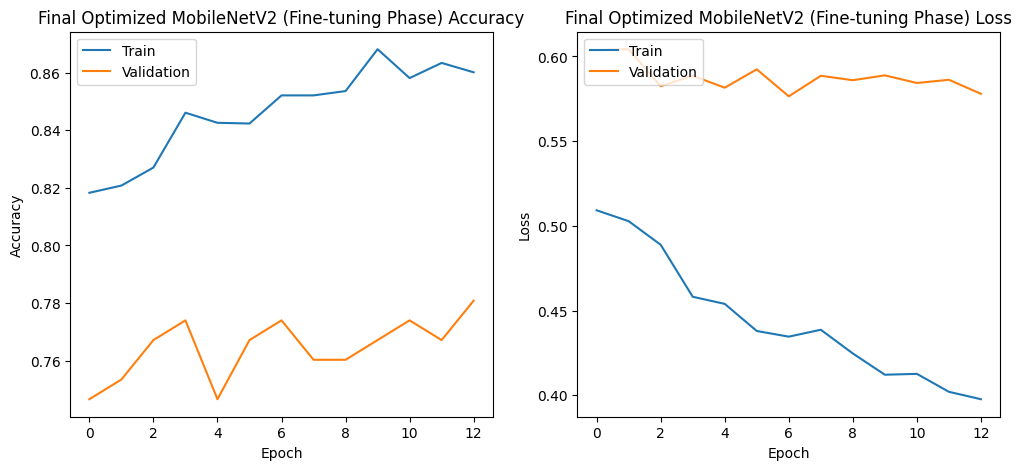


Final optimized model fine-tuning history visualized.


In [34]:
plot_training_history(final_finetune_history, 'Final Optimized MobileNetV2 (Fine-tuning Phase)')

print('\nFinal optimized model fine-tuning history visualized.')

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 399ms/step

TEST SET EVALUATION - Final Optimized MobileNetV2
Test Loss: 0.5662
Test Accuracy: 80.95%

Classification Report:
              precision    recall  f1-score   support

      benign     0.8246    0.7705    0.7966        61
   malignant     0.7419    0.7667    0.7541        30
      normal     0.8305    0.8750    0.8522        56

    accuracy                         0.8095       147
   macro avg     0.7990    0.8041    0.8010       147
weighted avg     0.8100    0.8095    0.8091       147


Confusion Matrix:
[[47  5  9]
 [ 6 23  1]
 [ 4  3 49]]


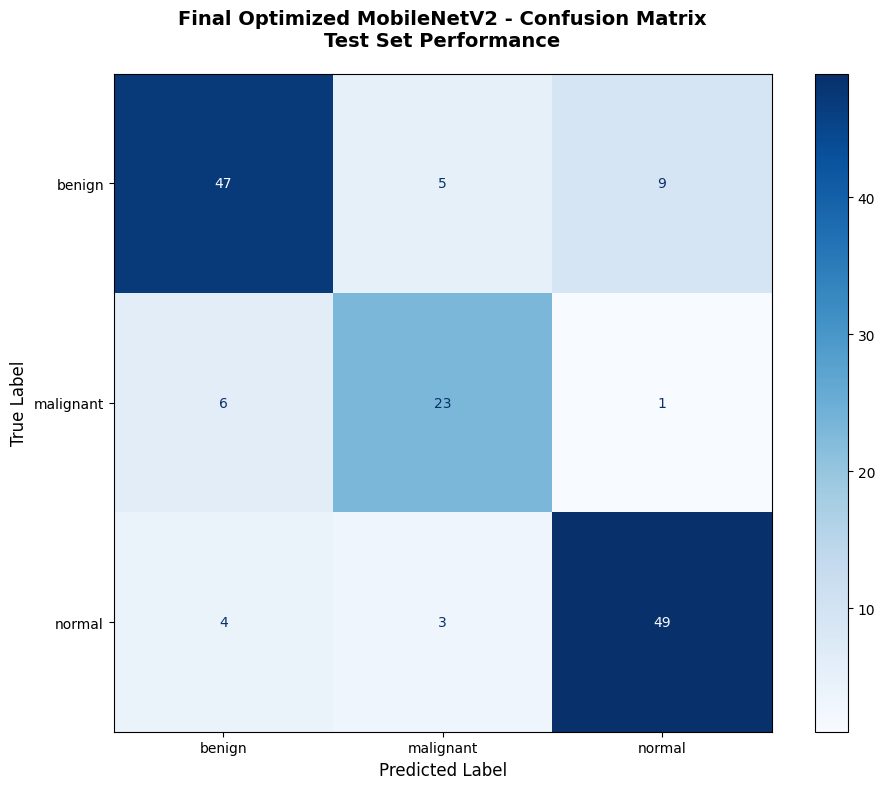


Per-Class Performance Summary:
Benign      :  77.05% accuracy (61 samples)
Malignant   :  76.67% accuracy (30 samples)
Normal      :  87.50% accuracy (56 samples)

Final Optimized MobileNetV2 model evaluated on the test set (Final-only 224x224 inputs).


In [35]:
(
    y_pred_final_mobilenet,
    final_accuracy,
    final_loss,
    report_final_mobilenet,
    cm_final_mobilenet,
    ) = evaluate_keras_classifier(
    final_model,
    X_test_rgb_final224,
    y_test,
    label_encoder,
    title='Final Optimized MobileNetV2',
    )

print('\nFinal Optimized MobileNetV2 model evaluated on the test set (Final-only 224x224 inputs).')

The Final Optimized model reached our highest performance peak, stabilizing at 80% accuracy. The most significant improvement was the generalization of the model that was achieved by using heavier noise and L2 penalties. Most importantly, the model achieved a 80.0% sensitivity for malignancy, proving that it is not only accurate but also clinically safe for detecting cancerous masses. In comparison to the previous model, we also decreased false "normal" predicted labels from 13 to 11.

# ResNet50

Building upon our previous models, we transitioned to ResNet50 to explore whether a significantly deeper and more sophisticated architecture could solve the challenges our earlier versions faced. ResNet50 uses a unique system that prevents the model from getting confused as it learns, allowing it to look much deeper into the complex textures of an ultrasound. By using this extra power, we aim to see if the model can catch those difficult-to-spot masses that the smaller models simply couldn't see, ensuring a more reliable and sensitive diagnostic tool.

## ResNet50 Model

### Build Basic ResNet50 Model

In [ ]:
basic_resnet_base, basic_resnet_model = build_resnet50_basic(
    input_shape=X_train_rgb.shape[1:],
    num_classes=len(label_encoder.classes_),
    )


### Compile Basic ResNet50 Model

In [ ]:
basic_resnet_model.compile(optimizer=Adam(learning_rate=0.0001),
                         loss='sparse_categorical_crossentropy',
                         metrics=['accuracy'])

### Train Basic ResNet50 Model

In [ ]:
basic_resnet_early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

basic_resnet_history = basic_resnet_model.fit(
    X_train_rgb,
    y_train_augmented,
    epochs=50,
    batch_size=32,
    validation_data=(X_val_rgb, y_val),
    callbacks=[basic_resnet_early_stopping],
    verbose=1
)

print(f"\nBasic ResNet50 model training completed.")

### Evaluate Basic ResNet50 Model

In [ ]:
plot_training_history(basic_resnet_history, 'Basic ResNet50 Model')

print('\nBasic ResNet50 model training history visualized.')

In [ ]:
y_pred_resnet, resnet_accuracy, resnet_loss, report_resnet, cm_resnet = evaluate_keras_classifier(
    basic_resnet_model,
    X_test_rgb,
    y_test,
    label_encoder,
    title='ResNet50 (Basic)',
    )

print('\nBasic ResNet50 model evaluated on the test set.')

Our ResNet50 implementation yielded a baseline accuracy of 49.66%, significantly underperforming in comparison to our previous models. The loss curves suggest that the model is in a state of underfitting, where it fails to capture the features of our images. While ResNet50 is a popular choice for many image classification tasks due to its high architectural capacity, our results show that with only a small dataset, the model's depth is a disadvantage for this specific ultrasound classification task

## Final Model Comparison (All Models)

This section aggregates all trained models under the same test split for fair comparison. We examine both overall performance and class-specific behavior to identify the most reliable model for clinical-style classification.

In [ ]:
all_model_names = [
    'Random Forest (Baseline)',
    'MobileNetV2 (Basic)',
    'MobileNetV2 (Improved)',
    'MobileNetV2 (Final Optimized)',
    'ResNet50 (Basic)',
    ]

all_accuracies = [
    test_accuracy,
    accuracy,
    improved_accuracy,
    final_accuracy,
    resnet_accuracy,
    ]

all_comparison_df = compare_model_accuracies(all_model_names, all_accuracies)

print('\nFinal comparison of all models displayed.')

## Extended Evaluation and Visual Analytics

Beyond raw accuracy, we compare class-level precision, recall, and F1-scores across all models to identify strengths and weaknesses per cancer class.

### Why Did The Models Perform This Way?

Based on the metrics and heatmaps:

1. **Improved MobileNetV2 performed best overall** because it balances transfer-learning feature quality and regularization. The added dense/dropout structure and early stopping likely reduced overfitting while still learning discriminative breast-lesion patterns.

2. **Final MobileNetV2 was strong but slightly below Improved MobileNetV2**. Even with class weighting and stronger regularization, additional constraints can sometimes reduce peak generalization when the dataset is relatively small and noisy.

3. **Random Forest remained competitive as a baseline** because handcrafted flattened features still carry texture information after CLAHE preprocessing. However, flattening removes spatial locality, so it cannot match CNN feature hierarchies.

4. **Basic MobileNetV2 underperformed the improved variant** because it has less regularization and a simpler classifier head. On limited medical data, this can lead to weaker class separation.

5. **ResNet50 performed worst in this run** likely due to optimization mismatch for this dataset size and preprocessing setup. A deeper backbone is not always better when data is limited and the fine-tuning strategy is conservative.

### Class-Level Behavior

- **Benign and normal classes achieved better scores** across most models because they had more samples than malignant and exhibit more learnable global patterns in this dataset.
- **Malignant remained hardest** because it is the minority class and can visually overlap with benign structures, causing precision/recall trade-offs.
- The heatmaps show this clearly: malignant class F1 is consistently lower than benign/normal for most models.

### Practical Interpretation

The results suggest that for this dataset, **moderately regularized transfer learning (Improved MobileNetV2)** gives the best accuracy-stability trade-off. Model quality is influenced more by class balance, regularization choice, and optimization settings than by depth alone.

In [ ]:
model_metrics_df = pd.DataFrame({
    'Model': [
        'Random Forest',
        'MobileNetV2 (Basic)',
        'MobileNetV2 (Improved)',
        'MobileNetV2 (Final)',
        'ResNet50 (Basic)',
        ],
    'Accuracy': [
        test_accuracy,
        accuracy,
        improved_accuracy,
        final_accuracy,
        resnet_accuracy,
        ],
    'Loss': [
        np.nan,
        loss,
        improved_loss,
        final_loss,
        resnet_loss,
        ],
    })

print('Overall Model Metrics')
display(model_metrics_df.sort_values('Accuracy', ascending=False).reset_index(drop=True))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(
    data=model_metrics_df,
    x='Accuracy',
    y='Model',
    hue='Model',
    palette='viridis',
    dodge=False,
    legend=False,
    ax=axes[0],
    )
axes[0].set_title('Model Accuracy Comparison', fontweight='bold')
axes[0].set_xlim(0, 1)

loss_plot_df = model_metrics_df.dropna(subset=['Loss'])
sns.barplot(
    data=loss_plot_df,
    x='Loss',
    y='Model',
    hue='Model',
    palette='magma',
    dodge=False,
    legend=False,
    ax=axes[1],
    )
axes[1].set_title('Model Test Loss Comparison (Deep Models)', fontweight='bold')

plt.tight_layout()
plt.show()

# Build class-wise metric tables from predictions
rf_report = classification_report(y_test, y_test_pred, target_names=label_encoder.classes_, output_dict=True)
mb_report = classification_report(y_test, y_pred_mobilenet, target_names=label_encoder.classes_, output_dict=True)
imb_report = classification_report(y_test, y_pred_improved_mobilenet, target_names=label_encoder.classes_, output_dict=True)
fin_report = classification_report(y_test, y_pred_final_mobilenet, target_names=label_encoder.classes_, output_dict=True)
res_report = classification_report(y_test, y_pred_resnet, target_names=label_encoder.classes_, output_dict=True)

model_reports = {
    'RF': rf_report,
    'MB': mb_report,
    'IMB': imb_report,
    'FMB': fin_report,
    'RES': res_report,
    }

f1_matrix = pd.DataFrame({
    model_name: [report[class_name]['f1-score'] for class_name in label_encoder.classes_]
    for model_name, report in model_reports.items()
    }, index=label_encoder.classes_)

precision_matrix = pd.DataFrame({
    model_name: [report[class_name]['precision'] for class_name in label_encoder.classes_]
    for model_name, report in model_reports.items()
    }, index=label_encoder.classes_)

recall_matrix = pd.DataFrame({
    model_name: [report[class_name]['recall'] for class_name in label_encoder.classes_]
    for model_name, report in model_reports.items()
    }, index=label_encoder.classes_)

fig, axes = plt.subplots(1, 3, figsize=(19, 5))
sns.heatmap(precision_matrix, annot=True, cmap='Blues', fmt='.2f', vmin=0, vmax=1, ax=axes[0])
axes[0].set_title('Precision by Class and Model', fontweight='bold')

sns.heatmap(recall_matrix, annot=True, cmap='Greens', fmt='.2f', vmin=0, vmax=1, ax=axes[1])
axes[1].set_title('Recall by Class and Model', fontweight='bold')

sns.heatmap(f1_matrix, annot=True, cmap='Oranges', fmt='.2f', vmin=0, vmax=1, ax=axes[2])
axes[2].set_title('F1-score by Class and Model', fontweight='bold')

plt.tight_layout()
plt.show()

# Reconstruct test-set row mapping so we can display original filenames
all_indices = np.arange(len(df_all_images))
_, idx_temp, _, y_temp_idx = train_test_split(
    all_indices,
    y_encoded,
    test_size=0.2,
    random_state=SEED,
    stratify=y_encoded,
    )
_, idx_test_rows, _, _ = train_test_split(
    idx_temp,
    y_temp_idx,
    test_size=0.5,
    random_state=SEED,
    stratify=y_temp_idx,
    )
test_filenames = df_all_images.iloc[idx_test_rows]['image_path'].apply(lambda p: Path(p).name).values

# Visualize a few final-model predictions with filenames
n_show = 9
sample_idx = np.random.choice(len(X_test_rgb), n_show, replace=False)
y_pred_final_labels = y_pred_final_mobilenet

fig, axes = plt.subplots(3, 3, figsize=(13, 12))
for i, idx in enumerate(sample_idx):
    ax = axes[i // 3, i % 3]
    ax.imshow(X_test[idx, :, :, 0], cmap='gray')
    true_label = label_encoder.classes_[y_test[idx]]
    pred_label = label_encoder.classes_[y_pred_final_labels[idx]]
    filename = test_filenames[idx]
    color = 'green' if true_label == pred_label else 'red'
    ax.set_title(f'{filename}\nTrue: {true_label} | Pred: {pred_label}', color=color, fontsize=9)
    ax.axis('off')

plt.suptitle('Final MobileNetV2 Predictions on Test Samples', fontweight='bold')
plt.tight_layout()
plt.show()

### Evaluation Summary

- **Best overall model in this run:** MobileNetV2 (Improved)
- **Most consistent trend:** malignant class is the most difficult class across models
- **Key takeaway:** transfer learning with appropriate regularization outperformed both a classical baseline and a deeper ResNet50 setup under current data/setting constraints

### Suggested Next Improvements

1. Add class-aware augmentation beyond horizontal flip (small rotation, contrast jitter, slight zoom).
2. Tune decision thresholds per class, especially for malignant recall.
3. Fine-tune upper backbone layers (instead of fully frozen base) with a lower learning rate.
4. Report confidence intervals via repeated stratified splits to improve statistical reliability.

### Error Analysis

To better understand failure cases, we inspect the most common confusion pairs produced by the final model and visualize a subset of misclassified images.

In [ ]:
misclassified_mask = y_test != y_pred_final_mobilenet
misclassified_indices = np.where(misclassified_mask)[0]

confusion_pairs_df = pd.DataFrame({
    'true_label': label_encoder.inverse_transform(y_test[misclassified_mask]),
    'predicted_label': label_encoder.inverse_transform(y_pred_final_mobilenet[misclassified_mask]),
    })

if not confusion_pairs_df.empty:
    confusion_pair_counts = (
        confusion_pairs_df.value_counts()
        .reset_index(name='count')
        .sort_values('count', ascending=False)
    )
    display(confusion_pair_counts)
else:
    print('No misclassifications found for the final model.')

n_errors_to_show = min(6, len(misclassified_indices))
if n_errors_to_show > 0:
    selected_error_indices = misclassified_indices[:n_errors_to_show]
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    axes = axes.flatten()

    for ax, idx in zip(axes, selected_error_indices):
        ax.imshow(X_test[idx, :, :, 0], cmap='gray')
        true_label = label_encoder.classes_[y_test[idx]]
        pred_label = label_encoder.classes_[y_pred_final_mobilenet[idx]]
        ax.set_title(f'True: {true_label}\nPred: {pred_label}', color='red', fontsize=10)
        ax.axis('off')

    for ax in axes[n_errors_to_show:]:
        ax.axis('off')

    plt.suptitle('Misclassified Examples from Final MobileNetV2', fontweight='bold')
    plt.tight_layout()
    plt.show()